
# pyunwrap: complete training pipeline

This notebook walks through the **full training chain** for `AmbiguityNet`,
end to end:

1. Generate synthetic InSAR training + validation scenes (multiple
   deformation types: Gaussian subsidence bowl, Mogi volcanic source, and a
   deformation-free control).
2. Normalize and tile the scenes into overlapping patches, saved to HDF5.
3. Build `InSARTileDataset`s and inspect a sample.
4. Build `AmbiguityNet` and `PhysicsInformedUnwrapLoss`.
5. Train with `Trainer` (curriculum learning + AdamW/cosine schedule +
   gradient clipping + periodic validation), and inspect the training curves.
6. Visually compare predicted vs. ground-truth unwrapped phase on a
   validation tile.

**Note on scale:** to keep this notebook fast and reproducible on a laptop
CPU, it trains a small number of epochs on small (128x128) scenes. A
production run would use `pyunwrap.training.trainer.build_argparser`'s CLI
(`pyunwrap-train`) with the full 60-epoch / 3-stage curriculum schedule
described in `Trainer`'s docstring, larger scenes, and a GPU.


In [1]:

import math
import random

import numpy as np
import torch
import matplotlib.pyplot as plt

from pyunwrap.synthetic.generator import InSARSyntheticGenerator
from pyunwrap.data.preprocessing import (
    NormalizedRasters, iter_tiles, save_tiles_hdf5,
    normalize_phase, normalize_coherence, normalize_amplitude,
)
from pyunwrap.data.dataloader import InSARTileDataset
from pyunwrap.models.ambiguity_net import AmbiguityNet
from pyunwrap.models.losses import PhysicsInformedUnwrapLoss
from pyunwrap.training.trainer import Trainer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

OUT_DIR = "nb_training_run"
print("Setup complete.")


Setup complete.


## 1. Generate synthetic training & validation data

In [2]:

def build_tile_dataset(path, n_scenes, size, tile_size, overlap, seed):
    # Generate `n_scenes` synthetic InSAR scenes (cycling through
    # deformation types), tile each, and save all tiles to one HDF5 file.
    gen = InSARSyntheticGenerator(size=size, seed=seed)
    deformation_types = ["gaussian_bowl", "mogi", "none"]
    all_tiles = []
    for i in range(n_scenes):
        deformation_type = deformation_types[i % len(deformation_types)]
        sample = gen.generate_sample(deformation_type=deformation_type)
        rasters = NormalizedRasters(
            wrapped_phase=normalize_phase(sample.wrapped_phase),
            coherence=normalize_coherence(sample.coherence),
            amplitude=normalize_amplitude(sample.amplitude),
        )
        tiles = list(iter_tiles(
            rasters, true_unwrapped=sample.unwrapped_phase,
            tile_size=tile_size, overlap=overlap,
        ))
        all_tiles.extend(tiles)
    save_tiles_hdf5(all_tiles, path)
    return len(all_tiles)

n_train_tiles = build_tile_dataset(
    f"{OUT_DIR}/train_tiles.h5", n_scenes=8, size=128, tile_size=64, overlap=16, seed=SEED,
)
n_val_tiles = build_tile_dataset(
    f"{OUT_DIR}/val_tiles.h5", n_scenes=3, size=128, tile_size=64, overlap=16, seed=SEED + 1000,
)
print(f"Training tiles: {n_train_tiles}")
print(f"Validation tiles: {n_val_tiles}")


Training tiles: 72
Validation tiles: 27


## 2. Build datasets and inspect a sample

In [3]:

train_ds = InSARTileDataset(f"{OUT_DIR}/train_tiles.h5", augment=True, require_ground_truth=True, seed=SEED)
val_ds = InSARTileDataset(f"{OUT_DIR}/val_tiles.h5", augment=False, require_ground_truth=True, seed=SEED)

print(f"len(train_ds) = {len(train_ds)}")
print(f"len(val_ds)   = {len(val_ds)}")

sample = train_ds[0]
for key, tensor in sample.items():
    print(f"{key:16s} shape={tuple(tensor.shape)} dtype={tensor.dtype}")


len(train_ds) = 72
len(val_ds)   = 27
wrapped_phase    shape=(1, 64, 64) dtype=torch.float32
coherence        shape=(1, 64, 64) dtype=torch.float32
amplitude        shape=(1, 64, 64) dtype=torch.float32
true_unwrapped   shape=(1, 64, 64) dtype=torch.float32
true_ambiguity   shape=(1, 64, 64) dtype=torch.float32


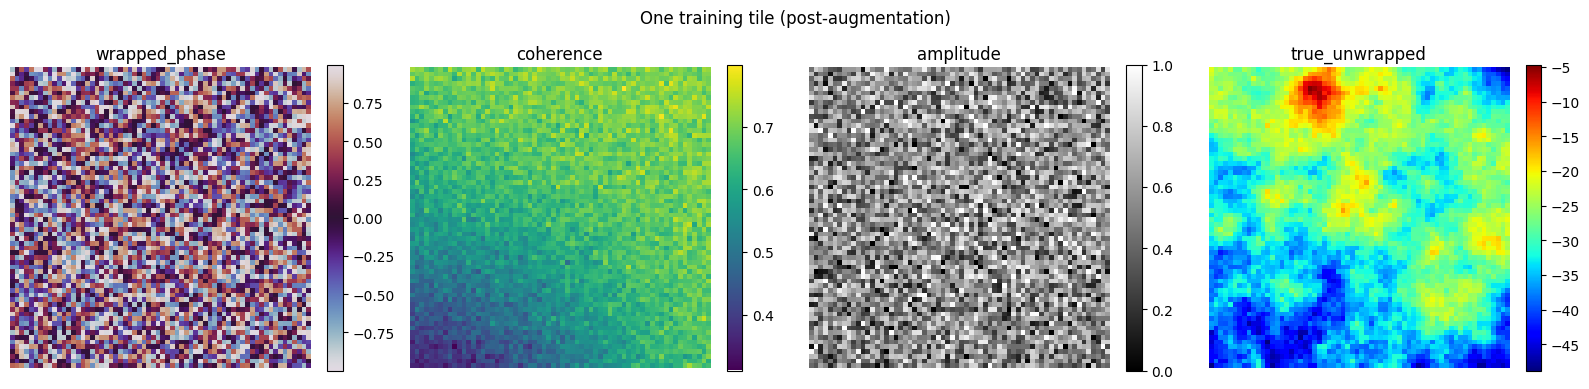

In [4]:

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ["wrapped_phase", "coherence", "amplitude", "true_unwrapped"]
cmaps = ["twilight", "viridis", "gray", "jet"]
for ax, key, cmap in zip(axes, titles, cmaps):
    im = ax.imshow(sample[key].squeeze(0).numpy(), cmap=cmap)
    ax.set_title(key)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("One training tile (post-augmentation)")
fig.tight_layout()
plt.show()


## 3. Build the model and loss

In [5]:

model = AmbiguityNet(pretrained=False, k_max=10.0)
criterion = PhysicsInformedUnwrapLoss()

n_params = sum(p.numel() for p in model.parameters())
print(f"AmbiguityNet parameters: {n_params:,}")
print(f"Loss weights: ambiguity={criterion.weight_ambiguity}, "
      f"rewrap={criterion.weight_rewrap}, smoothness={criterion.weight_smoothness}, "
      f"residue={criterion.weight_residue}")


AmbiguityNet parameters: 24,436,258
Loss weights: ambiguity=0.5, rewrap=0.3, smoothness=0.1, residue=0.1



## 4. Train

`Trainer` handles curriculum-filtered data loading, the AdamW + warmup/cosine
LR schedule, gradient clipping, periodic validation, checkpointing,
TensorBoard logging, and training-curve plotting.

This demo trains for a handful of epochs (all within curriculum stage 1,
since the full 3-stage schedule spans 60 epochs) -- long enough to see the
loss decrease and the curriculum subset size vary scene-to-scene, short
enough to run quickly here.


In [6]:

trainer = Trainer(
    model=model,
    train_dataset=train_ds,
    val_dataset=val_ds,
    out_dir=OUT_DIR,
    total_epochs=8,
    warmup_epochs=2,
    base_lr=1e-4,
    batch_size=4,
    num_workers=0,
    grad_clip_norm=1.0,
    validate_every=2,
    device="cpu",
    use_curriculum=True,
)
trainer.fit()


[CurriculumIndex] WARNING: epoch 1's curriculum filter matched 0 tiles; falling back to the full dataset for this epoch to avoid stalling training.
[Trainer] Epoch 1: curriculum subset size = 72 / 72


[Trainer] Epoch 1/8 loss=18.8205 lr=1.00e-04 (8.8s)
[CurriculumIndex] WARNING: epoch 2's curriculum filter matched 0 tiles; falling back to the full dataset for this epoch to avoid stalling training.
[Trainer] Epoch 2: curriculum subset size = 72 / 72


[Trainer] Epoch 2/8 loss=10.1670 lr=1.00e-04 (7.3s) | val_rmse=21.9066 rad val_pct<0.1rad=10.22% val_residues=0
[CurriculumIndex] WARNING: epoch 3's curriculum filter matched 0 tiles; falling back to the full dataset for this epoch to avoid stalling training.
[Trainer] Epoch 3: curriculum subset size = 72 / 72


[Trainer] Epoch 3/8 loss=7.9752 lr=9.33e-05 (7.6s)
[CurriculumIndex] WARNING: epoch 4's curriculum filter matched 0 tiles; falling back to the full dataset for this epoch to avoid stalling training.
[Trainer] Epoch 4: curriculum subset size = 72 / 72


[Trainer] Epoch 4/8 loss=7.9476 lr=7.50e-05 (7.4s) | val_rmse=21.6425 rad val_pct<0.1rad=8.70% val_residues=1
[CurriculumIndex] WARNING: epoch 5's curriculum filter matched 0 tiles; falling back to the full dataset for this epoch to avoid stalling training.
[Trainer] Epoch 5: curriculum subset size = 72 / 72


[Trainer] Epoch 5/8 loss=7.7516 lr=5.00e-05 (7.8s)
[CurriculumIndex] WARNING: epoch 6's curriculum filter matched 0 tiles; falling back to the full dataset for this epoch to avoid stalling training.
[Trainer] Epoch 6: curriculum subset size = 72 / 72


[Trainer] Epoch 6/8 loss=7.9283 lr=2.50e-05 (7.6s) | val_rmse=22.0371 rad val_pct<0.1rad=8.56% val_residues=0
[CurriculumIndex] WARNING: epoch 7's curriculum filter matched 0 tiles; falling back to the full dataset for this epoch to avoid stalling training.
[Trainer] Epoch 7: curriculum subset size = 72 / 72


[Trainer] Epoch 7/8 loss=7.5962 lr=6.70e-06 (7.9s)
[CurriculumIndex] WARNING: epoch 8's curriculum filter matched 0 tiles; falling back to the full dataset for this epoch to avoid stalling training.
[Trainer] Epoch 8: curriculum subset size = 72 / 72


[Trainer] Epoch 8/8 loss=7.2938 lr=0.00e+00 (7.6s) | val_rmse=21.9339 rad val_pct<0.1rad=8.63% val_residues=0


## 5. Inspect training curves

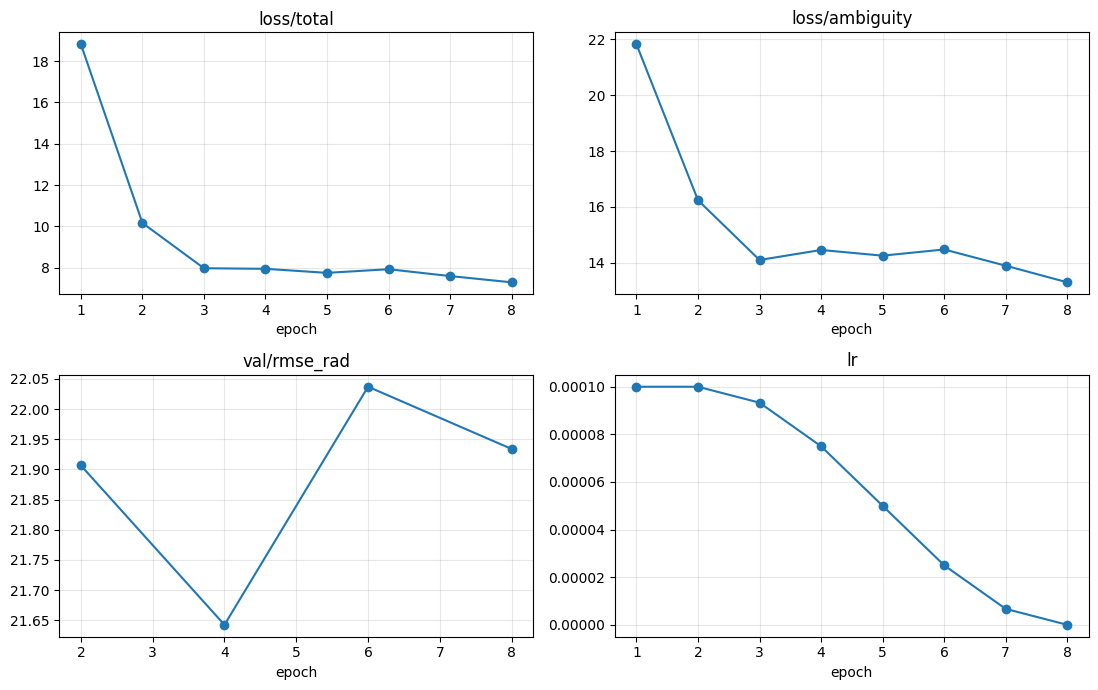

In [7]:

history = trainer.visualizer.history
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
plot_keys = ["loss/total", "loss/ambiguity", "val/rmse_rad", "lr"]
for ax, key in zip(axes.ravel(), plot_keys):
    if key not in history:
        ax.set_visible(False)
        continue
    epochs, values = zip(*history[key])
    ax.plot(epochs, values, marker="o")
    ax.set_title(key)
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


## 6. Visually compare predicted vs. ground-truth unwrapped phase

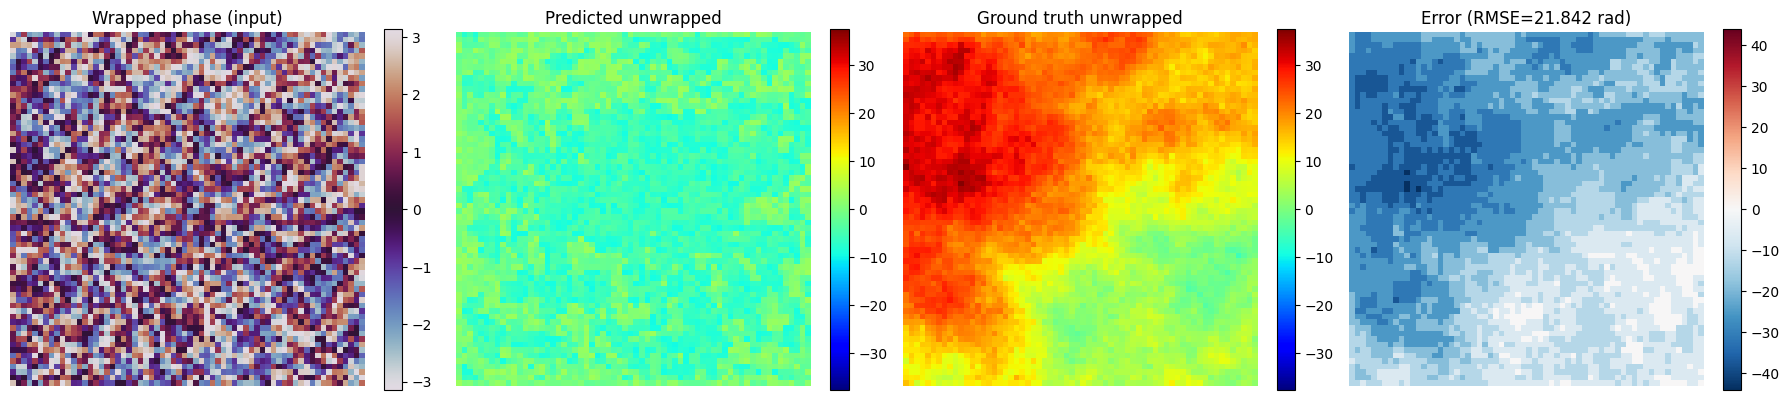

This is an early-stage model trained for only 8 epochs on a tiny dataset -- expect a high RMSE here. A full 60-epoch run on a larger, more diverse dataset is needed for production-quality unwrapping.


In [8]:

model.eval()
val_batch = val_ds[0]
x = torch.cat([
    val_batch["wrapped_phase"], val_batch["coherence"], val_batch["amplitude"],
], dim=0).unsqueeze(0)

with torch.no_grad():
    out = model(x)

predicted = out.phi_hat.squeeze().numpy()
true_unwrapped = val_batch["true_unwrapped"].squeeze(0).numpy()
wrapped = val_batch["wrapped_phase"].squeeze(0).numpy() * math.pi

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
im0 = axes[0].imshow(wrapped, cmap="twilight", vmin=-math.pi, vmax=math.pi)
axes[0].set_title("Wrapped phase (input)")
fig.colorbar(im0, ax=axes[0], fraction=0.046)

vmax = max(abs(predicted).max(), abs(true_unwrapped).max())
im1 = axes[1].imshow(predicted, cmap="jet", vmin=-vmax, vmax=vmax)
axes[1].set_title("Predicted unwrapped")
fig.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(true_unwrapped, cmap="jet", vmin=-vmax, vmax=vmax)
axes[2].set_title("Ground truth unwrapped")
fig.colorbar(im2, ax=axes[2], fraction=0.046)

error = predicted - true_unwrapped
err_vmax = max(abs(error).max(), 1e-6)
im3 = axes[3].imshow(error, cmap="RdBu_r", vmin=-err_vmax, vmax=err_vmax)
axes[3].set_title(f"Error (RMSE={np.sqrt((error**2).mean()):.3f} rad)")
fig.colorbar(im3, ax=axes[3], fraction=0.046)

for ax in axes:
    ax.axis("off")
fig.tight_layout()
plt.show()

print(f"This is an early-stage model trained for only 8 epochs on a tiny "
      f"dataset -- expect a high RMSE here. A full 60-epoch run on a larger, "
      f"more diverse dataset is needed for production-quality unwrapping.")



## Next steps

- See `02_full_pipeline.ipynb` for the complete chain: this training step,
  followed by tiled inference on a full-scene GeoTIFF, phase/residue
  analytics, explainability, and automated HTML report generation.
- For a production training run, use the CLI:
  ```bash
  pyunwrap-train --train-hdf5 train.h5 --val-hdf5 val.h5 \
      --epochs 60 --warmup-epochs 5 --finetune-start-epoch 55 \
      --finetune-hdf5 snaphu_pseudo_gt.h5 --out-dir runs/pyunwrap_v1
  ```
